In [1]:
import numpy as np
import matplotlib.pyplot as plt

from epymorph.kit import *
from epymorph.adrio import acs5

from epymorph.adrio import us_tiger

from epymorph.forecasting.pipeline import (
    PipelineConfig,
    Observations,
    ModelLink,
    UnknownParam,
)

from epymorph.forecasting.dynamic_params import BrownianMotion
from epymorph.forecasting.dynamic_params import GaussianPrior, ExponentialTransform

from epymorph.adrio.cdc import (
    InfluenzaStateHospitalizationDaily,
)
from epymorph.time import EveryNDays

from epymorph.initializer import RandomLocationsAndRandomSeed

In [2]:
rume = SingleStrataRUME.build(
    ipm=ipm.SIRH(),
    mm=mm.Centroids(),
    scope=StateScope.in_states(['AZ','CO','UT','NM'],year=2015),
    init=RandomLocationsAndRandomSeed(num_locations=4, seed_max=10_000),
    time_frame=TimeFrame.of("2022-09-15", 7 * 26 + 1),
    params={
        "beta": ExponentialTransform("log_beta"),
        "gamma": 0.2,
        "xi": 1 / 365,
        "hospitalization_prob": 200 / 100_000,
        "hospitalization_duration": 5.0,
        "population": acs5.Population(),
        "centroid": us_tiger.InternalPoint(),
    },
)

In [3]:
from epymorph.forecasting.likelihood import NegativeBinomialLikelihood

adrio_daily = InfluenzaStateHospitalizationDaily(column="admissions")

observations_daily = Observations(
    source=adrio_daily,
    model_link=ModelLink(
        quantity=rume.ipm.select.events("I->H"),
        time=rume.time_frame.select.all()
        .group(EveryNDays(1))
        .agg(),  # Changed from 1 day to 7 days
        geo=rume.scope.select.all(),
    ),
    likelihood=NegativeBinomialLikelihood(
        r=10
    ),  # Changed to a negative binomial likelihood
)

In [4]:
unknown_params = {
    "log_beta": UnknownParam(
        prior=GaussianPrior(mean=np.log(0.2), standard_deviation=0.5),
        dynamics=BrownianMotion(volatility=0.1),
    )
}

In [5]:
from epymorph.forecasting.pipeline import EnsembleKalmanFilterSimulator


num_realizations = 25

particle_filter_simulator = EnsembleKalmanFilterSimulator(
    config=PipelineConfig.from_rume(
        rume, num_realizations, unknown_params=unknown_params
    ),
    observations=observations_daily,
)

In [6]:
rng = np.random.default_rng(0)
particle_filter_output = particle_filter_simulator.run(rng=rng)

Observation: 0, Label: 2022-09-15, Time Frame: 2022-09-15 (1D)
Observation: 1, Label: 2022-09-16, Time Frame: 2022-09-16 (1D)
Observation: 2, Label: 2022-09-17, Time Frame: 2022-09-17 (1D)
Observation: 3, Label: 2022-09-18, Time Frame: 2022-09-18 (1D)
Observation: 4, Label: 2022-09-19, Time Frame: 2022-09-19 (1D)
Observation: 5, Label: 2022-09-20, Time Frame: 2022-09-20 (1D)
Observation: 6, Label: 2022-09-21, Time Frame: 2022-09-21 (1D)
Observation: 7, Label: 2022-09-22, Time Frame: 2022-09-22 (1D)
Observation: 8, Label: 2022-09-23, Time Frame: 2022-09-23 (1D)
Observation: 9, Label: 2022-09-24, Time Frame: 2022-09-24 (1D)
Observation: 10, Label: 2022-09-25, Time Frame: 2022-09-25 (1D)
Observation: 11, Label: 2022-09-26, Time Frame: 2022-09-26 (1D)
Observation: 12, Label: 2022-09-27, Time Frame: 2022-09-27 (1D)
Observation: 13, Label: 2022-09-28, Time Frame: 2022-09-28 (1D)
Observation: 14, Label: 2022-09-29, Time Frame: 2022-09-29 (1D)
Observation: 15, Label: 2022-09-30, Time Frame: 20

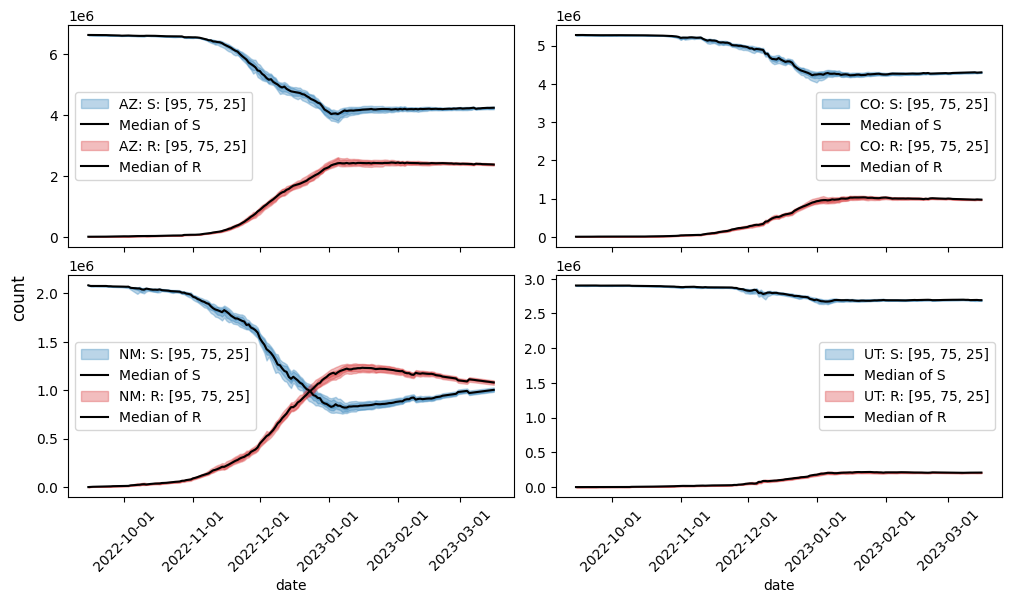

In [7]:
from epymorph.forecasting.filter_plot import PlotRendererPipeline

plotter = PlotRendererPipeline(particle_filter_output)
geo = rume.scope.select.all()
time = rume.time_frame.select.all().group('day').agg()
quantity = rume.ipm.select.compartments("S", "R")
plotter.quantiles(
    geo,
    time,
    quantity,
    ncols=2,
    legend="on",
    line_kwargs=[{"color": "black"}],
    fill_kwargs=[
        {"color": "tab:blue", "alpha": 0.3},
        {"color": "tab:red", "alpha": 0.3},
    ],  # Applies to the infill color
    credible_intervals=[95, 75, 25],
)

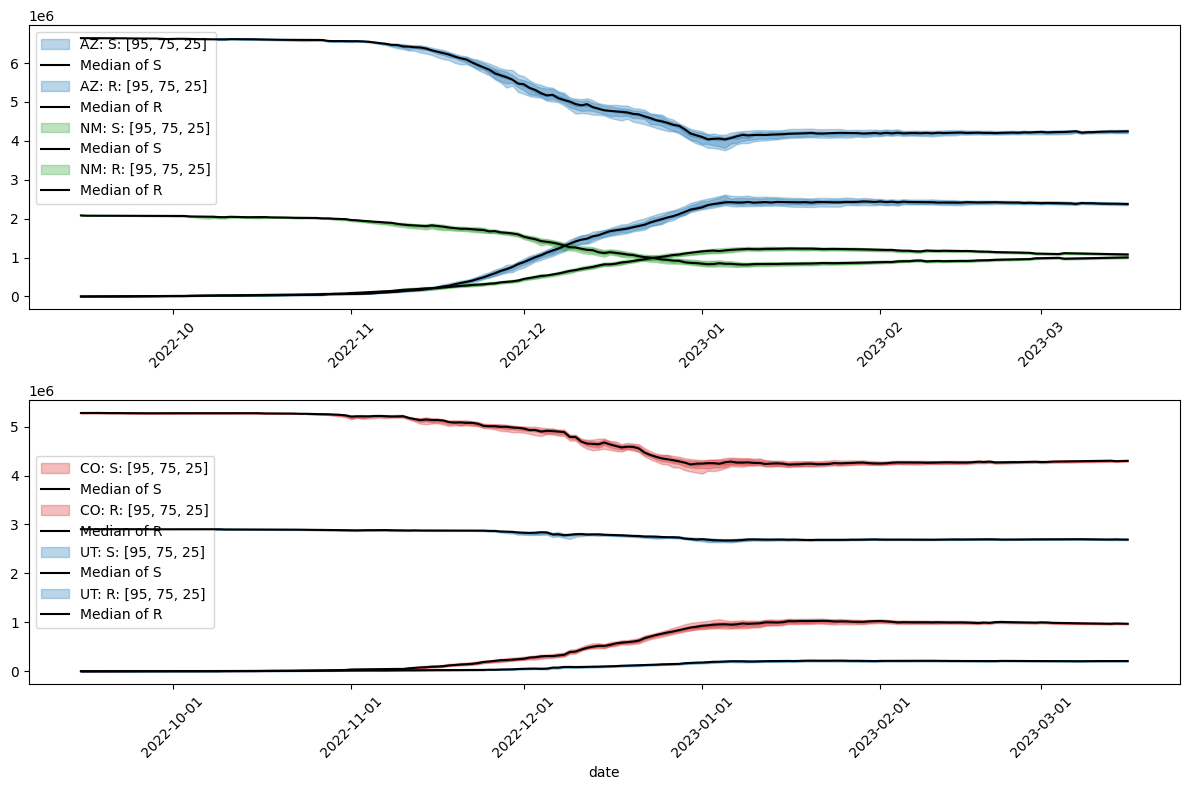

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))
geo = rume.scope.select.all()
time = rume.time_frame.select.all().group('day').agg()
quantity = rume.ipm.select.compartments("S","R")

plotter.quantiles_plt(
    np.array([axes]),
    geo,
    time,
    quantity,
    legend="on",
    kwarg_type="geo",
    line_kwargs=[{"color": "black"}],
    fill_kwargs=[
        {"color": "tab:blue", "alpha": 0.3},
        {"color": "tab:red", "alpha": 0.3},
        {"color": "tab:green", "alpha": 0.3},
    ],
    credible_intervals=[95, 75, 25],
)

fig.tight_layout()
plt.show()

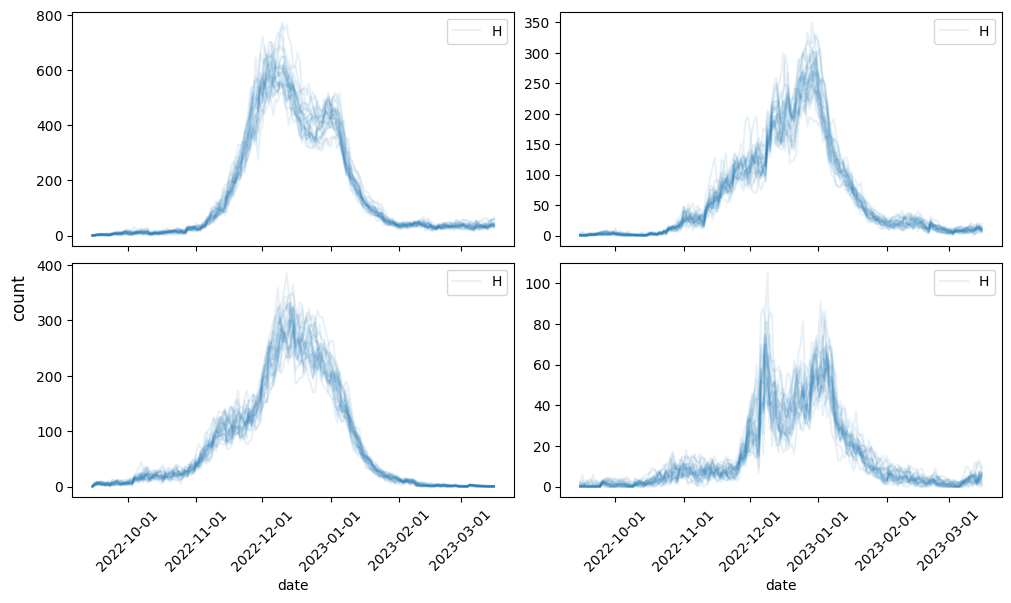

In [9]:
from epymorph.forecasting.filter_plot import PlotRendererPipeline

plotter = PlotRendererPipeline(particle_filter_output)
geo = rume.scope.select.all()
time = rume.time_frame.select.all().group('day').agg()
quantity = rume.ipm.select.compartments('H')
realization = particle_filter_output.select.all()

plotter.spaghetti(
    realization,
    geo,
    time,
    quantity,
    ncols = 2,
    time_format="date",
    line_kwargs=[{"color": "tab:blue","alpha":0.1},{"color":"tab:red","alpha":0.5}],
)


/tmp/ipykernel_812505/1818463445.py:54: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


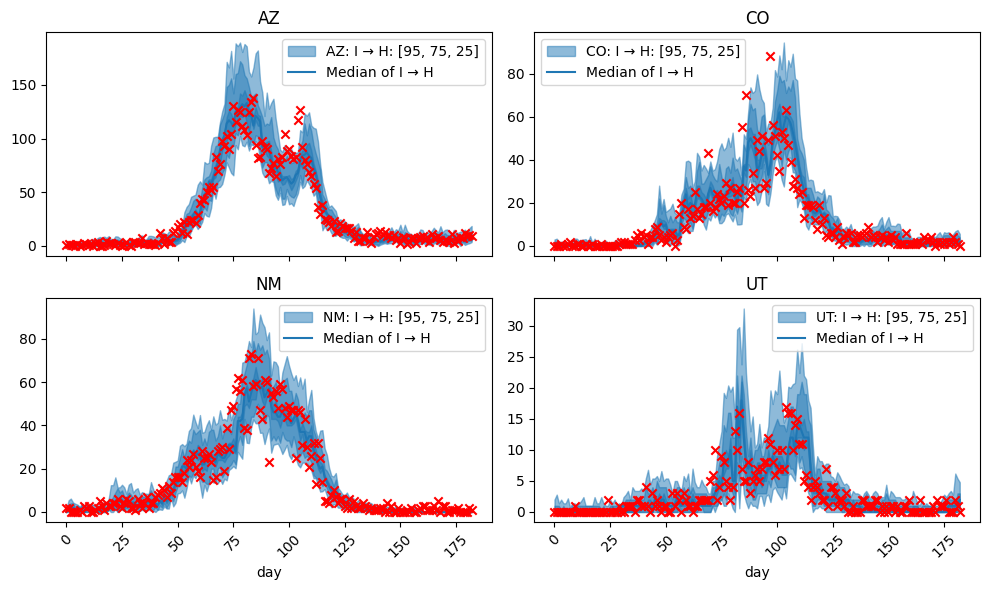

In [10]:
from math import ceil

quantity = rume.ipm.select.events("I->H")
time = rume.time_frame.select.all().group('day').agg()
data_date_range = np.arange(0, rume.time_frame.days, 1)

ncols = 2
nrows = ceil(geo.scope.nodes / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 5, nrows * 3),
    sharex=True,
    layout="constrained",
)

realization = particle_filter_output.select.all()

real_data_result = (
    observations_daily.source.with_context(scope=rume.scope, time_frame=rume.time_frame)
    .inspect()
    .result
)

real_data = real_data_result["value"]

for index, ax in enumerate(axes.ravel()):
    state = rume.scope.labels[index]
    geo = rume.scope.select.by_state(state)
    plotter.quantiles_plt(
        np.array([ax]),
        geo,
        time,
        quantity,
        legend="on",
        kwarg_type="geo",
        time_format = "day",
        fill_kwargs=[{"color": "tab:blue", "alpha": 0.5}],
        credible_intervals = [95,75,25]
    )

    ax.scatter(
        data_date_range,
        real_data[:, index],
        marker="x",
        color="red",
        label="real data",
        zorder=100,
    )

    ax.set_title(f"{state}")


fig.tight_layout()
plt.show()

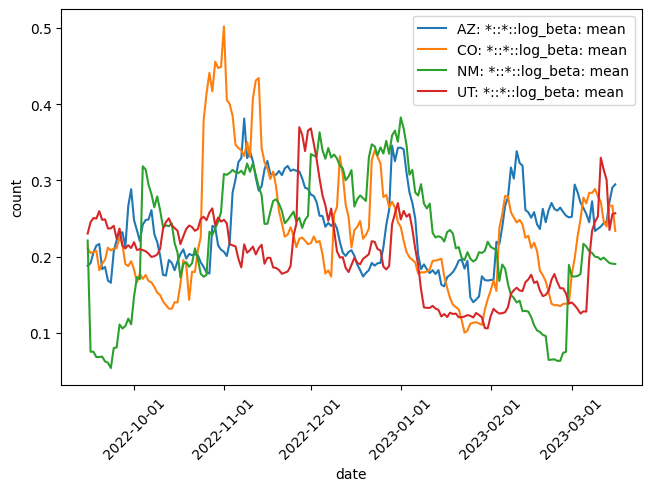

In [11]:
from math import exp

def exp_transform(data_df):
    # we have to be careful to avoid log(0)!
    log_value = data_df["value"].apply(lambda x: exp(x))
    return data_df.assign(value=log_value)

quantity = particle_filter_output.param_select.by_name("log_beta")
realization = particle_filter_output.select.all().agg(['mean'])
geo = rume.scope.select.all()
time = rume.time_frame.select.all().group('day').agg()
plotter.line(realization,geo,time,quantity,transform=exp_transform)

In [ ]:
# quantity = particle_filter_output.param_select.by_name("log_beta")
# realization = particle_filter_output.select.all()
# geo = rume.scope.select.all()
# time = rume.time_frame.select.days(100, 100).group("day").agg()

# plotter.histogram(
#     geo,
#     time,
#     quantity,
#     hist_kwargs=[{"bins": 10}],
#     ncols=2,
#     legend="on",
#     transform=exp_transform,
# )


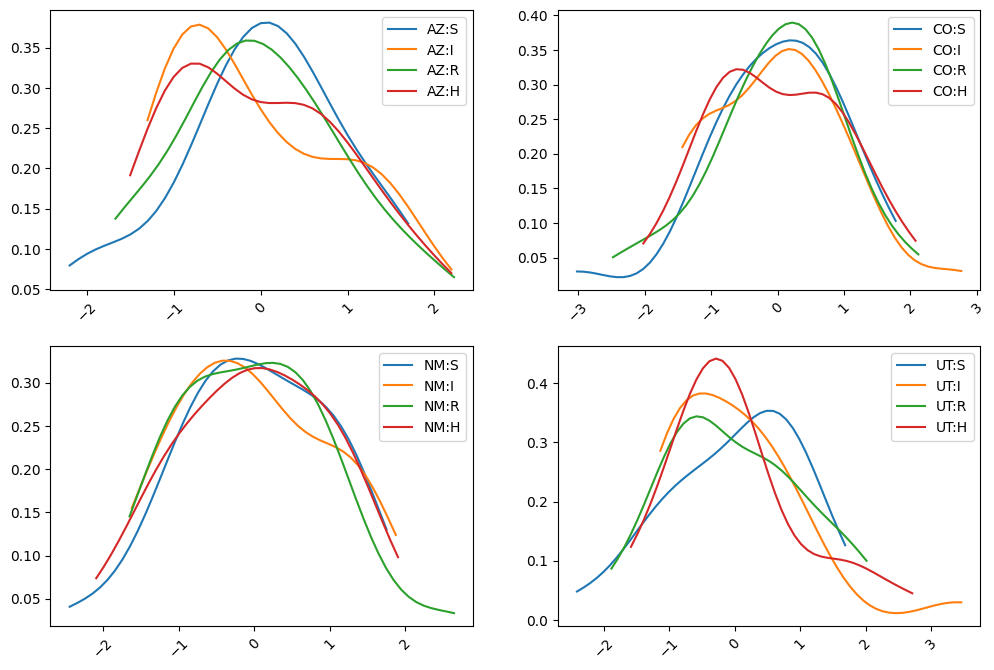

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
quantity = rume.ipm.select.compartments("S","I","R","H")
geo = rume.scope.select.all()
time = rume.time_frame.select.days(100, 100).group("day").agg()

def scale_transform(data_df):
    mean = np.mean(data_df["value"])
    std = np.std(data_df["value"])
    value = data_df["value"].apply(lambda x: (x - mean)/std)
    return data_df.assign(value=value)

plotter.kde_plt(
    np.array([axes]),
    geo,
    time,
    quantity,
    legend="on",
    label_format="{n}:{q}",
    bandwidth="scott",
    delta_t = 0.1,
    kwarg_type="geo",
    transform=scale_transform
)
plt.show()